# Player Churn Archetype & Predictive Analysis

The goal of this project is to develop a robust churn detection system for a mobile game. The methodology follows a two-stage approach:

- **Unsupervised Profiling:** Utilizing a K-Means Clustering model to segment the player base into distinct archetypes based on behavior and progression.

- **Supervised Prediction:** Integrating these cluster labels as features into a Random Forest classifier. This allows the model to obtain player "context" to predict the likelihood of churn and identify the specific drivers behind player attrition through SHAP value analysis.

In [1]:
import pandas as pd
import numpy as np
import pickle
import ast

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import silhouette_score, precision_score, accuracy_score, recall_score, f1_score, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay

from sklearn.ensemble import RandomForestClassifier
import shap

import seaborn as sns
import matplotlib.pyplot as plt


### Function definitions

In [2]:
def kmeans_inertia(num_clusters, x_vals):
    """
    Accepts as arguments list of ints and data array. 
    Fits a KMeans model where k = each value in the list of ints. 
    Returns each k-value's inertia appended to a list.
    """
    inertia = []
    for num in num_clusters:
        kms = KMeans(n_clusters=num, random_state=42)
        kms.fit(x_vals)
        inertia.append(kms.inertia_)

    return inertia

def kmeans_sil(num_clusters, x_vals):
    """
    Accepts as arguments list of ints and data array. 
    Fits a KMeans model where k = each value in the list of ints.
    Calculates a silhouette score for each k value. 
    Returns each k-value's silhouette score appended to a list.
    """
    sil_score = []
    for num in num_clusters:
        kms = KMeans(n_clusters=num, random_state=42)
        kms.fit(x_vals)
        sil_score.append(silhouette_score(x_vals, kms.labels_))

    return sil_score

def classification_scores(y_val, y_pred):
    """
    Accepts as arguments a list of values predicted and a list of values to test. 
    Calculates recall, precision, accuracy and F1 scores. 
    Returns a dictionary with all the scores.
    """
    scores = [recall_score, precision_score, accuracy_score, f1_score]
    result = {func.__name__:func(y_val,y_pred) for func in scores}
    return result

### Import dataset

In [3]:
#df_gcp = pd.read_csv('Data/sql_df.csv')
df_gcp = pd.read_csv('Data/bquxjob_71813456_19e3c131c40.csv')
df_gcp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18025 entries, 0 to 18024
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                18025 non-null  object 
 1   AvatarLevel       18025 non-null  int64  
 2   Gold              18025 non-null  int64  
 3   Gems              18025 non-null  int64  
 4   Purchases         18025 non-null  object 
 5   VipLevel          18025 non-null  int64  
 6   TotalPlay         18025 non-null  int64  
 7   TotalWon          18025 non-null  int64  
 8   TotalLost         18025 non-null  int64  
 9   FirstInstallDate  18025 non-null  object 
 10  LastSeenDate      18025 non-null  object 
 11  Card_score        18025 non-null  float64
 12  TotalStars        18025 non-null  int64  
 13  Overall_progress  18025 non-null  float64
dtypes: float64(2), int64(8), object(4)
memory usage: 1.9+ MB


## Feature engineering

The `Purchases` column contains dictionary objects. It is transformed to represent the total count of purchases made.

In [4]:
df_gcp['Purchases'] = df_gcp['Purchases'].apply(ast.literal_eval)
df_gcp['N_purchases'] = df_gcp['Purchases'].apply(lambda x: sum(x.values()))

# remove users with no purchases and some VipLevel.
invalid_purchasers = df_gcp[(df_gcp['N_purchases'] == 0) & (df_gcp['VipLevel'] > 0)].index
df_gcp = df_gcp.drop(invalid_purchasers).reset_index(drop=True)

Date formatting is applied, and engineered features are calculated.

In [5]:
current_date = pd.to_datetime('2024-04-13 00:00:00+00:00', errors='coerce')

# format datetime columns
df_gcp['FirstInstallDate'] = pd.to_datetime(df_gcp['FirstInstallDate'], utc=True, errors='coerce')
df_gcp['LastSeenDate'] = pd.to_datetime(df_gcp['LastSeenDate'], utc=True, errors='coerce')

df_gcp['Active_window'] = (df_gcp['LastSeenDate'] - df_gcp['FirstInstallDate']).dt.days
df_gcp = df_gcp[df_gcp['Active_window'] >= 0]  # Filter out negative days since install values

df_gcp['Tenure'] = (current_date - df_gcp['FirstInstallDate']).dt.days

# How much did they play while they were "active"
df_gcp['Play_intensity'] = df_gcp['TotalPlay'] / (df_gcp['Active_window'])

df_gcp['Win_rate'] = df_gcp['TotalWon'] / (df_gcp['TotalPlay'])

#drop no longer necessary columns
df_gcp = df_gcp.drop(columns=['Purchases', 'TotalLost', 'TotalWon', 'TotalPlay', 'TotalStars', 'Gold'])

Handling `Play_intensity` outliers to remove corrupted data

In [6]:
# remove users with very high average games played per day.
q1 = df_gcp['Play_intensity'].quantile(0.25)
q3 = df_gcp['Play_intensity'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
print(f"Upper Bound: {upper_bound}")
df_gcp = df_gcp[df_gcp['Play_intensity'] <= upper_bound]

Upper Bound: 41.14096091164827


Finally, the target variable, `Churned`, is defined. A player is flagged as churned (1) if they have been inactive for 14 or more days—a standard benchmark for casual mobile games. Otherwise, they are active (0).

In [7]:
# Estimate if the player has churned 
df_gcp['Churned'] = (current_date - df_gcp['LastSeenDate']).dt.days >= 14

Before selecting the features used for the model, a correlation table is created.

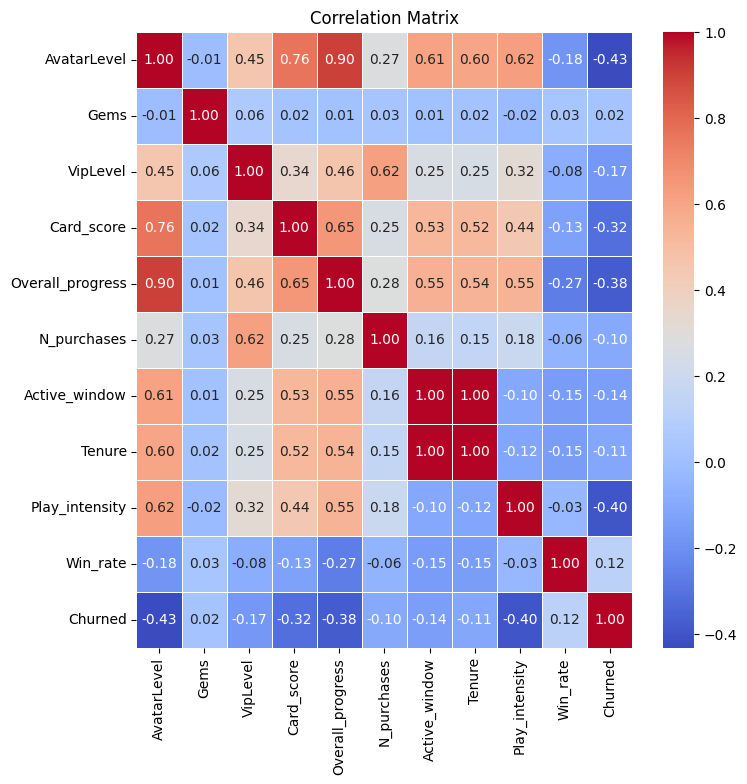

In [8]:
df_ = df_gcp.drop(columns=['ID', 'LastSeenDate', 'FirstInstallDate'])
corr = df_.corr()
plt.figure(figsize=(8, 8))
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5
            )
plt.title('Correlation Matrix')
plt.show()

From the correlation matrix it can be observed that some variables are highly correlated and can be ignored as features in order to avoid multicollinearity. For example, there is a high correlation between `AvatarLevel`, `overall_progress` and `cards_collected`. also `VipLevel` and `n_purchases` are highly correlated.

### Feature selection
These features are selected to train the models:

- `Overall_progress`: It’s highly correlated with all other progression metrics. It summarizes how deep into the game the player is.

- `Card_score`: This is the overall card score calculated based on the levels and rarity of the cards in the player's collection.

- `Play_intensity`: This represents how much did users play while they were "active". For two users with the same "active" period, the highest value tells which player is more engaged.

- `Win_rate`: This is the total games won compared to the total games played.

- `VipLevel`: This is an indicator of "Lifetime Value." It has correlation with 'n_purchases', but 'VipLevel' represents better the amount spent, and not just the quantity.

- `Gems`: Player with high gem balance are more likely to stay engaged with the game than those with low balance.

- `Tenure`: It represents for how long have been the players around. It tells if a player have just finished the FTUE or if it an experienced player.

In [9]:
# Select features and target columns
df = df_gcp[['Overall_progress', 'Card_score', 'Play_intensity', 'Win_rate', 'VipLevel', 'Gems', 'Tenure', 'Churned']].copy() #

Before segmenting the data, it is important to transform the features `Gems`, `ViPLevel` and `Card_score` as they have a very skewed distribution, this is, that very few players have huge amounts of gems, have reached very high VIP levels and/or have very powerful cards. 

In [10]:
df['Gems'] = np.log1p(df['Gems'])
df['VipLevel'] = np.log1p(df['VipLevel'])
df['Card_score'] = np.log1p(df['Card_score'])

## K-means clustering model
The objective in this step is to identify player profiles.

The first step is to isolate the target variable and the features.

In [11]:
X= df.copy()
# Isolate target variable
y = X['Churned']
# Isolate features
X = X.drop(['Churned'], axis=1)

The data is split in train/validation/test sets with a 80/20/20 proportion.

In [12]:
# Split the data into training and testing sets
X_tr, X_test, y_tr, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Split the training data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_tr, y_tr, test_size=0.25, random_state=42, stratify=y_tr)

for i in [X_train, X_test, X_val, y_train, y_test, y_val]: print(i.shape) 

(10617, 7)
(3539, 7)
(3539, 7)
(10617,)
(3539,)
(3539,)


To train the K-means clustering model the training data needs to be scaled, because the algorithm calculates the distance between points to group then.

In [13]:
X_train_scaled = StandardScaler().fit_transform(X_train)
X_val_scaled = StandardScaler().fit_transform(X_val)
X_test_scaled = StandardScaler().fit_transform(X_test)

In order to determine the right number of clusters, the best values for K, the elbow method or inertia is calculated

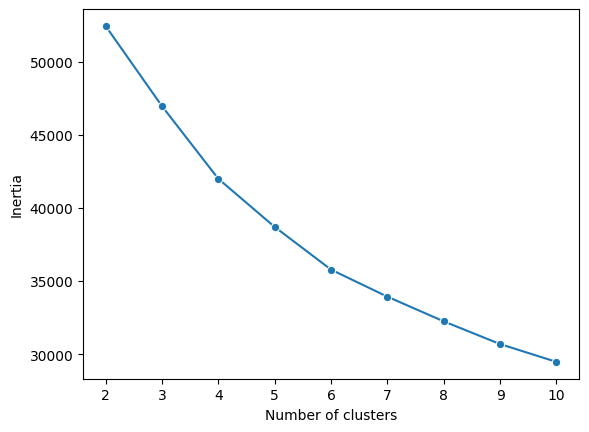

In [14]:
num_clusters = [i for i in range(2, 11)]

inertia = kmeans_inertia(num_clusters, X_train_scaled)
plot = sns.lineplot(x=num_clusters, y=inertia, marker = 'o')
plot.set_xlabel("Number of clusters");
plot.set_ylabel("Inertia");

The 'elbow' of the inertia plot is not obvious, but there are subtle rate decrease at k=6, indicating a good balance between a low number of clusters and the grouped datapoints.

Inertia is paired with the Silhouette Score, that will measure how well the data points fit into the cluster assigned compared to other clusters.

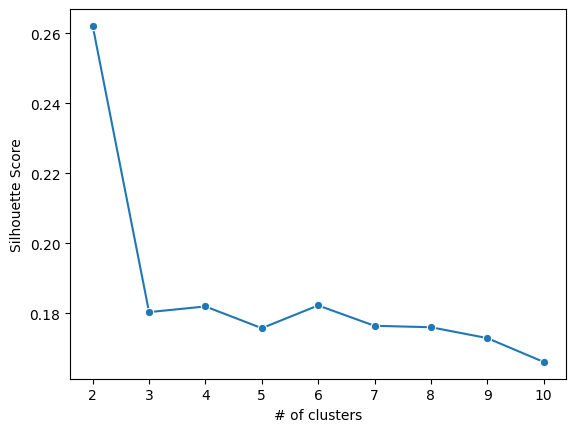

In [15]:
sil_score = kmeans_sil(num_clusters, X_train_scaled)
plot = sns.lineplot(x=num_clusters, y=sil_score, marker = 'o')
plot.set_xlabel("# of clusters");
plot.set_ylabel("Silhouette Score");

The silhouette chart indicates k=2 is the optimal number of clusters. However, having only two clusters won't give good insights about the users. There are local peaks that **k=6** and **k=8** wich could give a better representation of churned users and allow for specific targetting. K=6 is selected in favour of the inertia observed above.

In [16]:
kmeans6 = KMeans(n_clusters=6, random_state=42)
kmeans6.fit(X_train_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",6
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


The model is ready and now the different clusters can be displayed and compared. this will allow recognize and classify the different user profiles compared against the churned players.

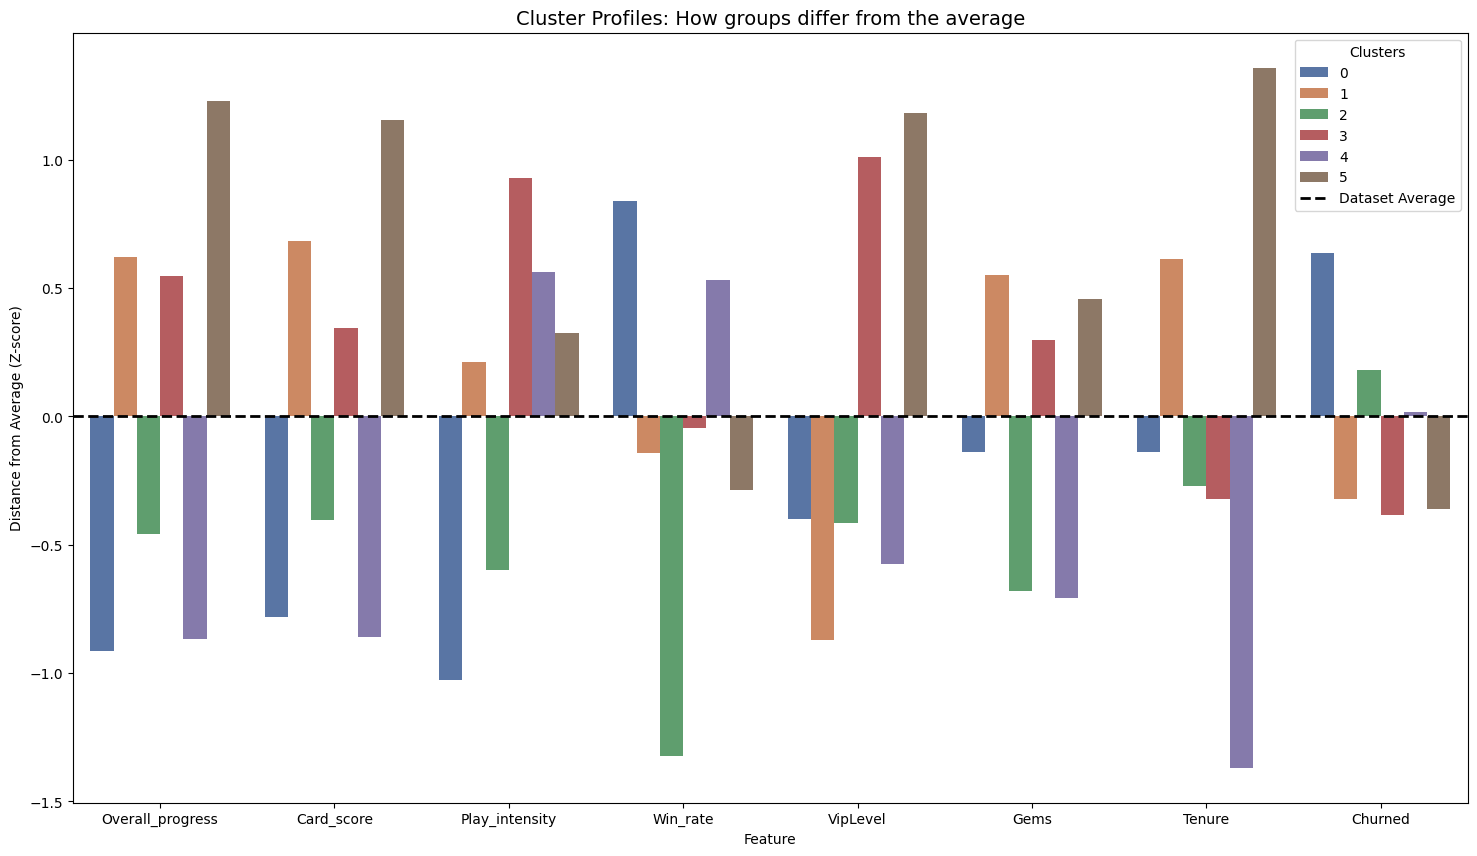

In [ ]:
# Scale the data (Z-scores)
scaler = StandardScaler()

features = X_train.copy()
features['Churned'] = y_train.values
scaled_features = pd.DataFrame(scaler.fit_transform(features), columns=features.columns)

# Add the cluster column after scaling
scaled_features['Cluster'] = kmeans6.labels_

# Group by cluster and get the mean Z-score
cluster_profiles = scaled_features.groupby('Cluster').mean().reset_index()

# Reshape for plotting
melted_df = cluster_profiles.melt(id_vars='Cluster', var_name='Feature', value_name='Z-score')
#melted_df.to_csv("cluster_profiles.csv", index=False)

# Plot
plt.figure(figsize=(18, 10))
sns.barplot(data=melted_df, x='Feature', y='Z-score', hue='Cluster', palette='deep')

# Add a "Baseline" line at 0
plt.axhline(0, color='black', linestyle='--', linewidth=2, label='Dataset Average')

plt.title('Cluster Profiles: How groups differ from the average', fontsize=14)
plt.ylabel('Distance from Average (Z-score)')
plt.legend(title='Clusters', loc='upper right')
plt.show()

From this plot we can now describe the user profiles as follows:

**Cluster 0: New players (Neutral Risk)**

- Lowest tenure (-1.36) and lowest progress, but high play intensity (+0.59) and high win rates. These players just downloaded the game and are getting out of the First Time User Experience (FTUE) phase. They are winning easily the first campaign levels and playing obsessively. They are at average risk. The real test will be whether they transition into Grinders (Cluster 1) or Frustrated (Cluster 2) once the game gets harder.

**Cluster 1: Grinders (Safe)**
- High tenure (+0.60), good progress, and strong card scores, but they have the lowest VIP level (-0.86) of any group. These are classic Free-to-Play veterans. They don't spend money, but they make up for it with consistency and time. They are at a safe, low risk of churning.

**Cluster 2: Furstrated (Elevated Risk)**
- This cluster suffers from an abysmal win rate (-1.28) combined with low play intensity, progress, and gem count. They are losing frequently and, as a result, they aren't playing much or progressing. They are at an elevated risk of churning, likely due to poor game experience.

**Cluster 3: Fans (Safe)**

- They max out the charts on progress (+1.25), card score (+1.18), VIP Level (+1.20), and tenure (+1.37). Interestingly, their win rate is slightly below average. These are the most valuable lifetime players. They have been around the longest and spend the most. They are  at a very low risk of churning. They are heavily invested in their accounts.

**Cluster 4: Bored (Critical Risk)**

- This group has the highest churn risk (+0.63) and the lowest play intensity (-1.03). They have a remarkably high win rate (+0.88) because the game isn't challenging enough, or the core loop isn't hooking them. They are top priority for churn prevention. They need deeper end-game mechanics or faster difficulty scaling.

**Cluster 5: Fast progress (Safest)**

- Below-average tenure (-0.31), but the highest play intensity (+0.89) and a massive VIP Level (+1.01). These are relatively new players who are aggressively spending to catch up to the veterans. They are hyper-engaged and progressing rapidly. They are at the lowest churn risk of all. They are entirely captivated by the game right now.

## Random Forest Model
For churn prediction, Recall is the most important metric because missing a customer who is about to leave (a False Negative) is usually more expensive than offering a discount to a loyal one.

The first step is to check for the data balance.

In [18]:
y_train.value_counts(normalize=True)

Churned
False    0.73128
True     0.26872
Name: proportion, dtype: float64

The data has a class inbalanced of 74/26, meaning the users flag as churened are less represented in the data set. This would introduce bias in the model if not adressed.

The new feature `Cluster` obtaned from the K-means model is added to the features for the RF tmodel training. Note that this variable is a raw number (no One-Hot encoded), as the Random Forest's structure is robust enough to handle these integer labels as decision splits.

In [19]:
X_train['Cluster'] = kmeans6.predict(X_train_scaled)
X_val['Cluster'] = kmeans6.predict(X_val_scaled)
X_test['Cluster'] = kmeans6.predict(X_test_scaled)

In [20]:
# Instantiate the random forest classifier
rf = RandomForestClassifier(class_weight='balanced_subsample',random_state=42)

# Create a dictionary of hyperparameters to tune
cv_params = {'n_estimators': [300,500],
             'max_depth': [20, None],
             'max_features': ['sqrt'],
             'min_samples_leaf': [25,50,100],
             }

# Define a list of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1']

# Instantiate the GridSearchCV object
rf_cv = GridSearchCV(rf, cv_params, scoring=scoring, cv=5, refit='recall')

Train the model

In [21]:
%%time

rf_cv.fit(X_train, y_train)
#pickle.dump(rf_cv, open('./Models/rf_cv.sav', 'wb'))

# uncomment this if the model has been trained and saved
#rf_cv = pickle.load(open('./models/rf_cv.sav', 'rb'))

rf_cv.best_params_

CPU times: user 3min 18s, sys: 6.18 s, total: 3min 24s
Wall time: 3min 26s


{'max_depth': 20,
 'max_features': 'sqrt',
 'min_samples_leaf': 100,
 'n_estimators': 500}

In [22]:
# Examine best recall score

rf_cv.best_score_

np.float64(0.7227455679478908)

The best predictor recall score is 0.7265, meaning that this model is 72.6% good at spotting a user that is about to churn.

### Model Validation

The model best model's racall score is 72.6% with the training data. This score can be improved by adjusting the threshold. It can be reduced in order to reduce the amount of costumers leaving the game unrecognised as churners (False Positives). This tuning will cause the model to be less precise, but it is better to flag costumers that are not leaving the game as churners.

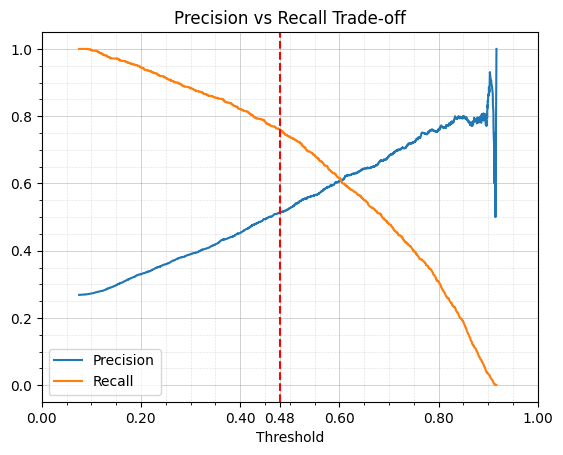

In [23]:
# Set custom trheshold for Recall score
probs = rf_cv.best_estimator_.predict_proba(X_val)[:, 1]
threshold = 0.48

precision, recall, thresholds = precision_recall_curve(y_val, probs)

plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.axvline(x=threshold, color='r', linestyle='--')
current_ticks = list(plt.xticks()[0])
plt.xticks(current_ticks + [threshold])
plt.minorticks_on()
plt.grid(which='major', color='gray', linewidth=0.5, alpha=0.5)
plt.grid(which='minor', color='gray', linestyle=':', linewidth=0.4, alpha=0.5)
plt.xlabel("Threshold")
plt.title("Precision vs Recall Trade-off")
plt.legend()
plt.show()

In the plot above it can beseen how modifying the threshold will affect Recall and Precision scores. By default the threshold is set to 0.5, reducing it to 0.48 will slightly improve the Recall, reducing the Precision score. from a business point of view, having less precision means that the model will apply new strategies (like special offers, gifts) to users that are not leaving the game, but on the other hand the model will spot more users that are quietly leaving the game, which can be more expensive in the long term.

In [24]:
y_pred = (probs >= threshold).astype(int)

classification_scores(y_val, y_pred)

{'recall_score': 0.7602523659305994,
 'precision_score': 0.5127659574468085,
 'accuracy_score': 0.7414523876801357,
 'f1_score': 0.6124523506988564}

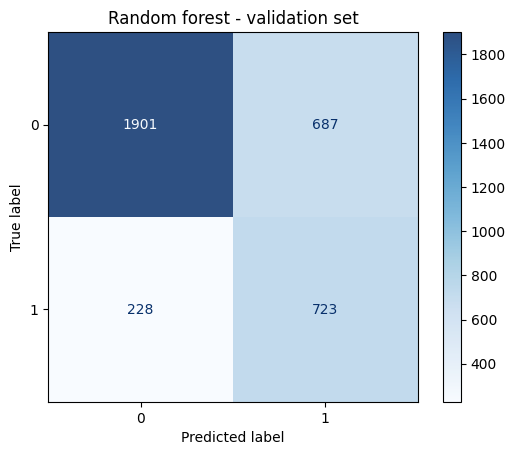

In [25]:
# Compute values for confusion matrix
rf_cm = confusion_matrix(y_val, y_pred)

# Create display of confusion matrix
rf_ax = ConfusionMatrixDisplay(confusion_matrix=rf_cm, display_labels=None)

# Plot confusion matrix
rf_ax.plot(
    cmap='Blues',
    im_kw={'alpha': 0.85}
)

# Display plot
plt.title('Random forest - validation set');
plt.grid(False)
plt.show()

The confusion matrix shows that only 256 churning users were not detected by the model. It also shows how the model flags churning users correctly half of the times (Precision = 51.7%)

#### SHAP explainer

A SHAP Explainer will interpret the models by quantifying how much each individual feature contributes to the churn risk increase or decrease.

In [26]:
# Create the  SHAP explainer
best_rf = rf_cv.best_estimator_
explainer = shap.TreeExplainer(best_rf)

Text(0.5, 1.0, 'Validation Data')

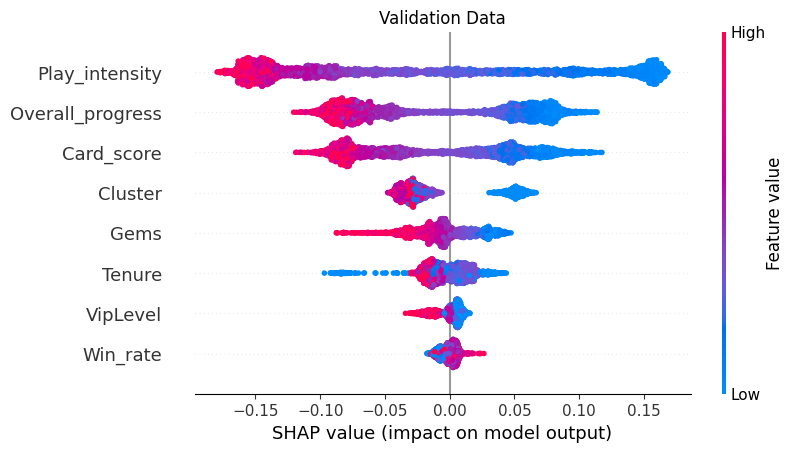

In [27]:
shap_values = explainer(X_val)

# Plot global importance (Summary/Beeswarm plot)
ax=shap.plots.beeswarm(shap_values[:, :, 1], show=False)
ax.set_title('Validation Data')

The Random Forest is essentially validating your K-Means strategy.

- `Play_intensity` is clearly the most important feature. The plot shows a massive blue cluster on the right, meaning low play intensity is the strongest predictor of churn. Even if a player has great cards at a high level or has consumed a big part of the game content, if they stop playing "intensely," they are likely gone.

- `Overall_progress` and `Card_score` follow a similar pattern. High values (red) are pushed to the left (reducing churn risk). This confirms that "Investment" is a shield. Players who have spent time grinding or building a deck have a much higher retention.

- `Win_rate` is at the bottom. While it does impact churn, the model weights it much less than activity. This explains why the "Bored" profile (high win rate but low intensity) is such a high risk, the lack of intensity "outvotes" the fact that they are winning.

- `Tenure` has some outliers where low tenure (blue) actually decreases churn risk. This likely represents your "Recruits" (Cluster4) who are new and haven't had the chance to churn yet.

#### SHAP for cluster 4 (Bored)

Text(0.5, 1.0, 'Validation Data - Cluster 4')

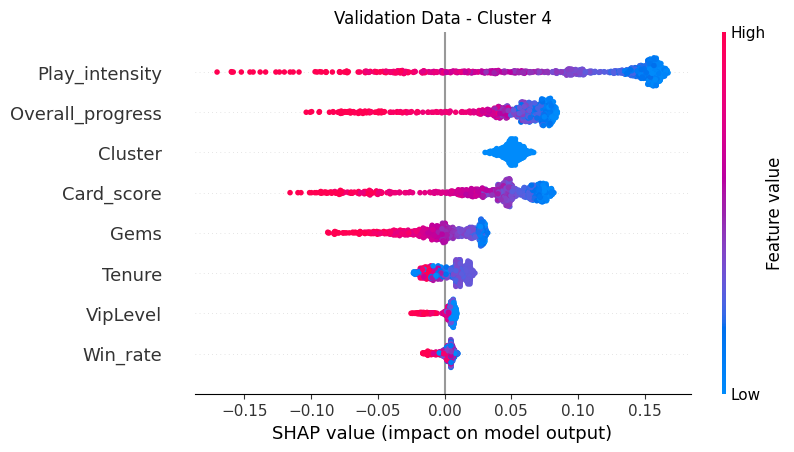

In [33]:
X_val_4 = X_val[X_val['Cluster']==0] #Bored
shap_values = explainer(X_val_4)

# 2. Plot global importance (Summary/Beeswarm plot)
ax = shap.plots.beeswarm(shap_values[:,:, 1], show=False)
ax.set_title('Validation Data - Cluster 4')

The SHAP plot reveals why they are at the highest risk. Even though they have high win rates (which should reduce churn), their `Play_intensity` and `Overall_progress` are low/negative. The model doesn't see "losing" as their problem.

The Cluster feature itself has a strong positive SHAP value (blue dots on the right). This means the model has learned that simply being in this cluster inherently increases churn risk, likely because the "Boredom" factor isn't fully captured by the other variables alone.

#### SHAP for cluster 2 (Frustrated)

Text(0.5, 1.0, 'Validation Data - Cluster 2')

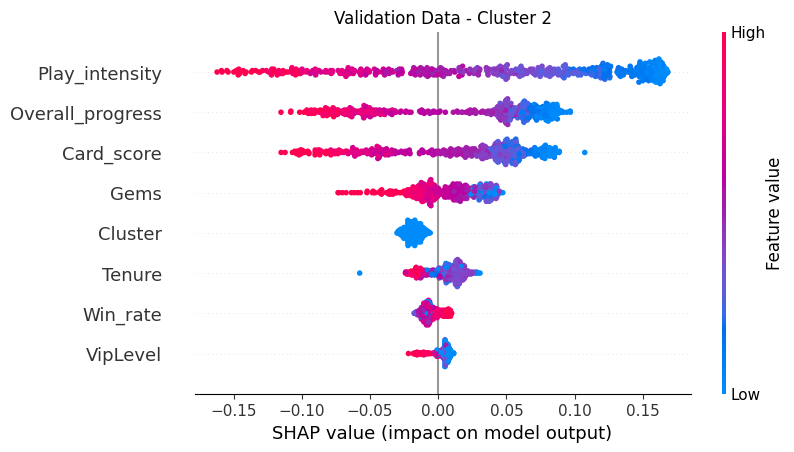

In [34]:
X_val_2 = X_val[X_val['Cluster']==2]
shap_values = explainer(X_val_2)

# 2. Plot global importance (Summary/Beeswarm plot)
ax = shap.plots.beeswarm(shap_values[:,:, 1], show=False)
ax.set_title('Validation Data - Cluster 2')

This plot reveals the "Friction" these players feel unlike the "Bored" group, `Win_rate` here shows that the red dots (low win rate) are pushing them toward churn.

`Card_score` and `Overall_progress` have different distributions. These players haven't built the "Retention Shield" that the veterans have. They are losing matches and they don't have enough "invested" in their account to justify the frustration.

### Model Test

The test data set is used now to prove that the model works with unseen data.

In [30]:
probs = rf_cv.best_estimator_.predict_proba(X_test)[:, 1]
y_pred = (probs >= threshold).astype(int)

In [31]:
classification_scores(y_test, y_pred)

{'recall_score': 0.7665615141955836,
 'precision_score': 0.5240833932422717,
 'accuracy_score': 0.7502119242723934,
 'f1_score': 0.6225448334756618}

The scores are in general a bit better but it proves that the model is robust and didn't overfit.

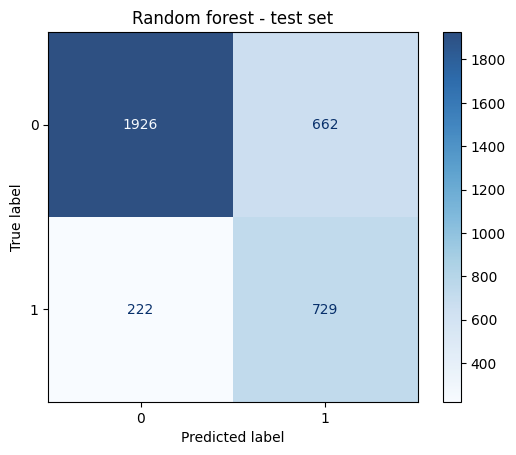

In [32]:
# Compute values for confusion matrix
rf_cm = confusion_matrix(y_test, y_pred)

# Create display of confusion matrix
rf_ax = ConfusionMatrixDisplay(confusion_matrix=rf_cm, display_labels=None)

# Plot confusion matrix
rf_ax.plot(
    cmap='Blues',
    im_kw={'alpha': 0.85}
)

# Display plot
plt.title('Random forest - test set');
plt.grid(False)
plt.show()

## Conclusions

- `Play_intensity`, `Overall_progress`, and `Card_score` are the primary churn drivers. The SHAP plot shows that low values (blue dots) for these features have a massive positive impact on churn.

- Players who aren't making progress or building their card collection early on are the most likely to drop off.

- The model has high Recall 74% (it's catching most churners) but lower Precision 52% (it's flagging many non-churners as "at risk"). For a churn system, it's better to send a gift to a loyal player than to miss a player who is actually leaving.

### Insights about the clusters at risk

-  The "Frustrated" (Cluster 2) players are losing a lot. Their SHAP plot shows that `Win_rate` has a higher negative impact here than in other groups. They are hitting a "difficulty wall" early and quitting out of frustration. 
    
    - Dynamic Difficulty Adjustment (DDA): If a player in this cluster loses 3 times in a row, subtly decrease the difficulty or give them a temporary buff.
    
    - Pity Mechanics: Offer "rebound" rewards after a loss streak to keep their Gems or Card_score moving upward despite the losses.


- The "Bored" (Cluster 4) players are winning more than average, but they aren't playing much. They are "bored winners." They likely haven't found the progression loop isn't compelling enough to make them spend their time.
    
    - Engagement Loops: Introduce daily login rewards or time-sensitive events specifically targeted at this cluster to increase their `Play_intensity`.
    
    - Progression Teasers: Show them what high-level gameplay looks like. Since they are good at the game (high win rate), challenge them with a "Hard Mode" or a competitive ladder to spark interest.

## Recomendations and next steps

- Since `Overall_progress` and `Card_score` are such heavy predictors, churning is happening early.
    - Smooth out the "Card Score" progression. If a player’s score is below the Z-score average by Level X, trigger a "Starter Pack" offer.
    - Check if there is a specific level or card-unlock threshold where progress slows down significantly.

- `Gems` is a mid-tier predictor. The SHAP plot shows that having low Gems leads to churn.
    - Give small amounts of gems for completing "Intensity" tasks (like playing 5 matches a day). This increases `Play_intensity` and provides the `Gems` needed to improve `Card_score`.

- Refining the Model
    - Feature Engineering: Since Tenure is a lower-impact feature, consider creating a "Velocity" feature (e.g., Progress / Tenure). A player who progresses quickly but then stops is a different churn risk than one who never progressed at all.

    - Address False Positives: To improve precision, look at the players your model thought would churn but didn't. What did they do? Did they join a guild? Did they make a small purchase? Use those actions as "Retention Nudges" for the at-risk clusters.
